# Employee Attrition Analysis & Predictive Modeling

### Objective: Analyze factors influencing employee turnover and build a production-ready classification pipeline.

### 1. Environment Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Modeling & Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, classification_report, confusion_matrix)

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Advanced ML
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')

## 2. Data Cleaning & Feature Engineering
Based on the initial inspection, we need to drop columns with zero variance or those that serve only as identifiers.

In [3]:
# 1. Drop irrelevant/constant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

# 2. Convert Target to binary if not already (it is 0/1 in your data)
# 3. Separate Features and Target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features: {len(numerical_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")

Numerical Features: 24
Categorical Features: 6


### 3. Exploratory Data Analysis (EDA)
Here are 10 key questions addressed through visualization and statistical insights.

#### Q1: What is the overall Attrition rate?

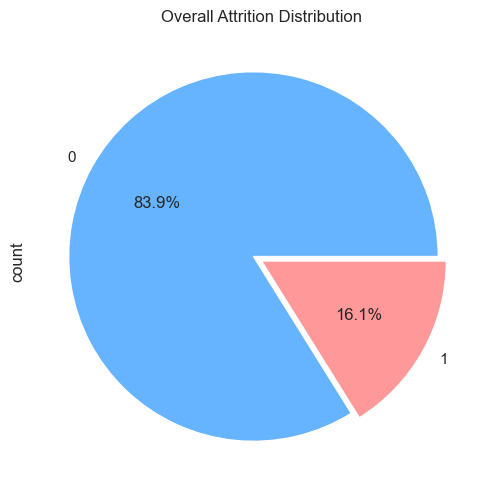

In [4]:
plt.figure(figsize=(6,6))
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], explode=(0.05,0))
plt.title('Overall Attrition Distribution')
plt.show()

#### Insight: The dataset is imbalanced (~16% attrition). SMOTE will be required.

#### Q2: Does Monthly Income impact Attrition?

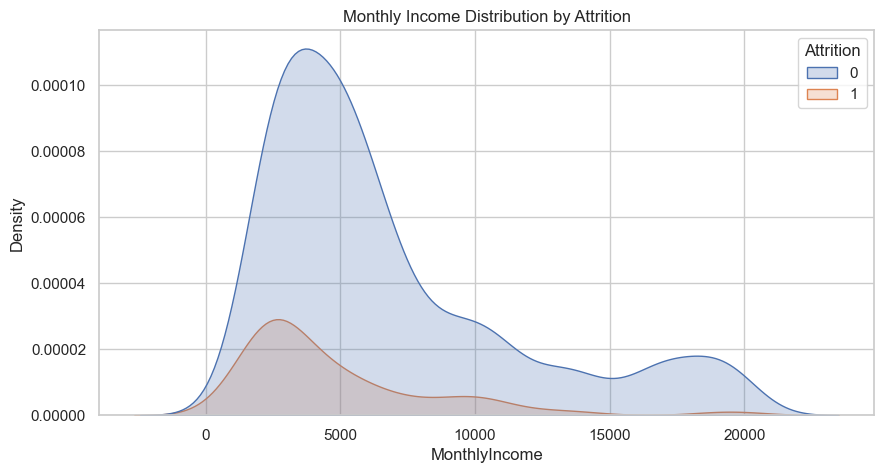

In [5]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', shade=True)
plt.title('Monthly Income Distribution by Attrition')
plt.show()

#### Insight: Employees with lower monthly income (below 5k) show significantly higher attrition.

#### Q3: How does Overtime affect turnover?

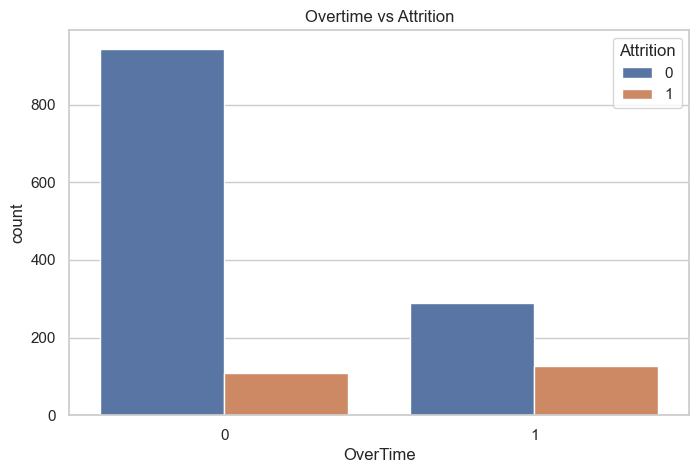

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Overtime vs Attrition')
plt.show()

#### Insight: Employees working overtime have a much higher proportion of leaving the company.

#### Q4: Which Job Role has the highest Attrition?

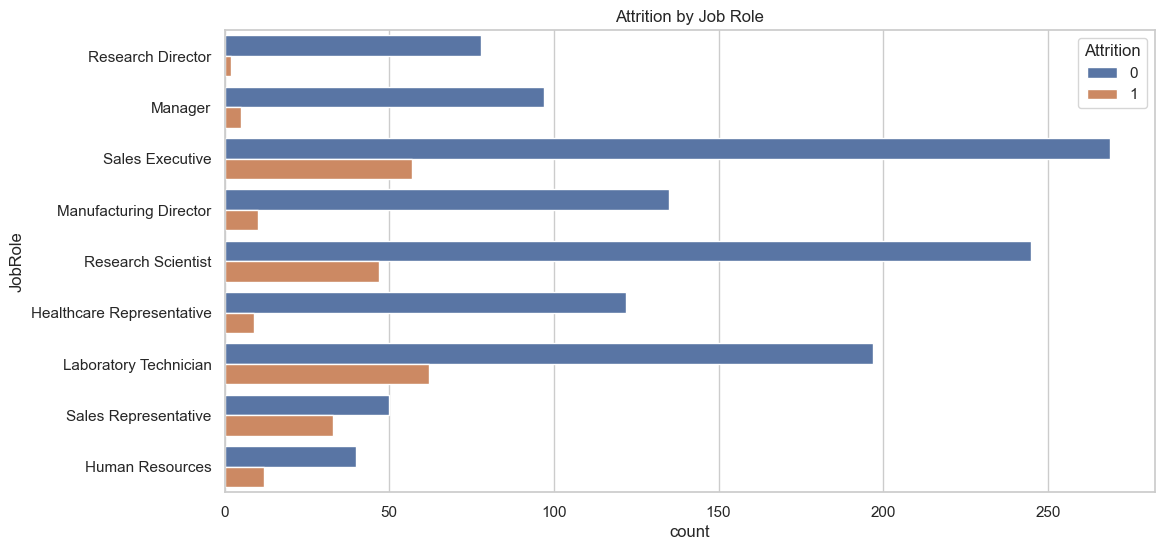

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='JobRole', hue='Attrition')
plt.title('Attrition by Job Role')
plt.show()

#### Insight: Sales Representatives and Laboratory Technicians show the highest churn rates.

#### Q5: Is there a correlation between Age and Attrition?

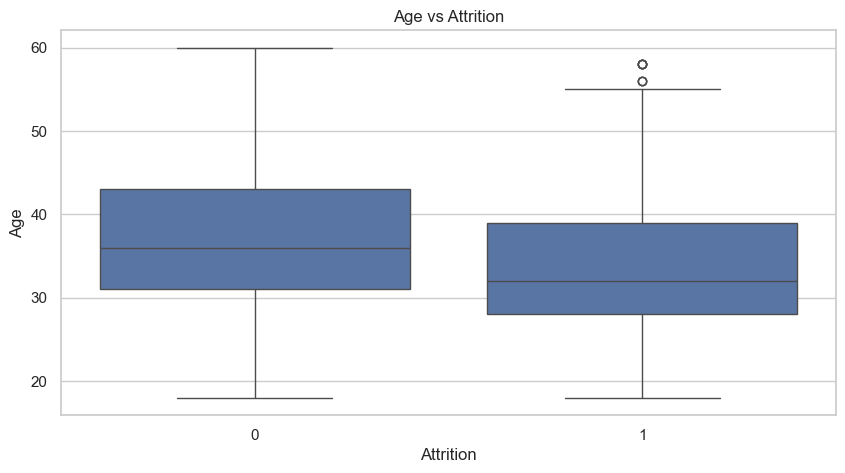

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('Age vs Attrition')
plt.show()

#### Insight: Younger employees (late 20s to early 30s) are more likely to leave.

#### Q6: Impact of Distance From Home?

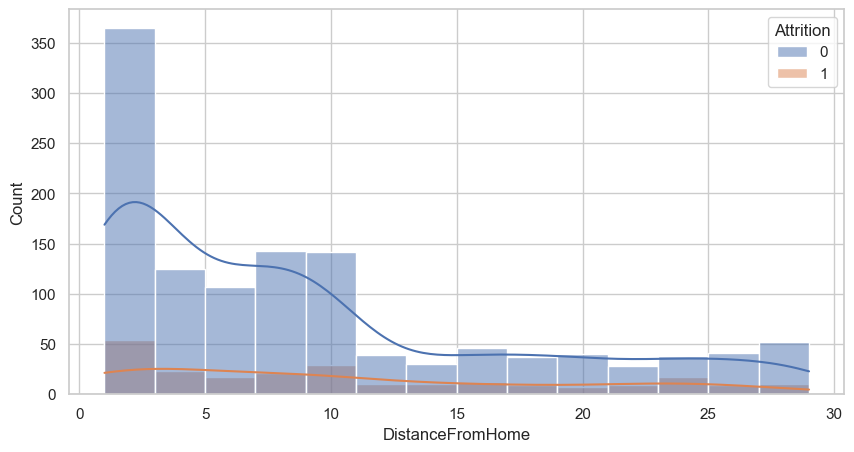

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition', kde=True)
plt.show()

#### Insight: Attrition increases as the distance from home increases, especially beyond 10-15 miles.

#### Q7: Does Stock Option Level correlate with retention?

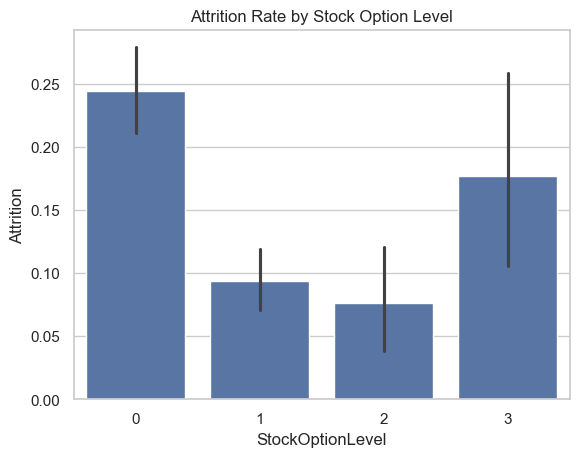

In [10]:
sns.barplot(x='StockOptionLevel', y='Attrition', data=df)
plt.title('Attrition Rate by Stock Option Level')
plt.show()

#### Insight: Employees with Level 1 or 2 stock options are more stable than those with Level 0.

#### Q8: Relationship between Years at Company and Attrition?

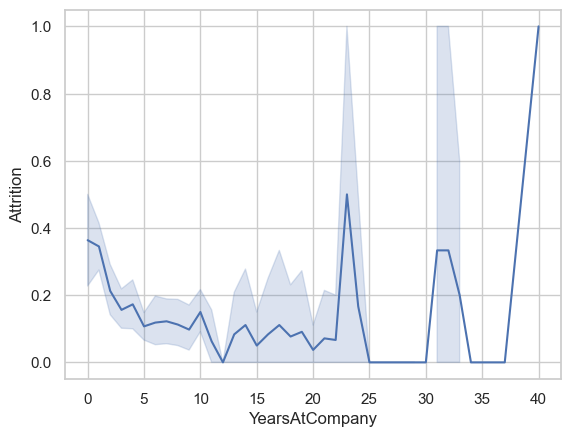

In [12]:
sns.lineplot(x='YearsAtCompany', y='Attrition', data=df)
plt.show()

#### Insight: The first 2-3 years are critical; attrition peaks early in the tenure.

#### Q9: Marital Status vs Attrition?

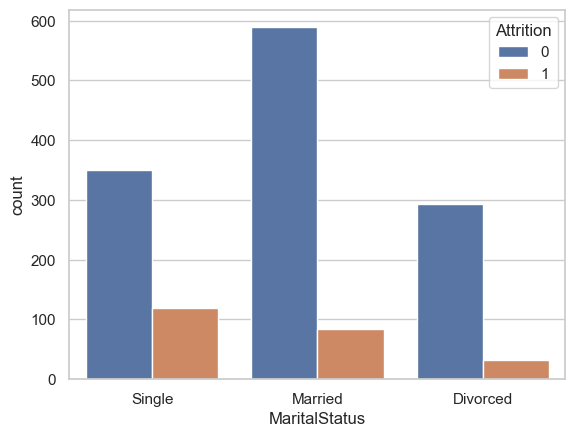

In [13]:
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.show()

#### Insight: Single employees have the highest attrition rate compared to Married or Divorced peers.

#### Q10: How does Work-Life Balance score influence the decision?

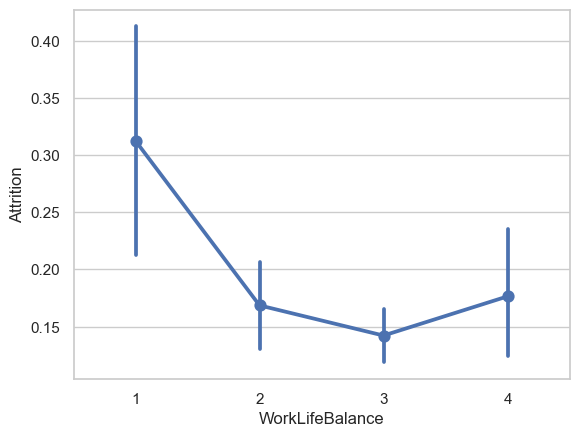

In [14]:
sns.pointplot(x='WorkLifeBalance', y='Attrition', data=df)
plt.show()

#### Insight: Low Work-Life Balance (Score 1) leads to drastically higher attrition.

### 4. Modeling Pipeline
We will create a pipeline that handles:

    Skewness/Outliers (RobustScaler)

    Categorical Encoding (OneHotEncoder)
    
    Dimensionality Reduction (PCA)
    
    Class Imbalance (SMOTE)

In [15]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing for numerical and categorical data
numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()) # Handles outliers and skewness better than StandardScaler
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Dimensionality Reduction Strategy
# We use PCA to reduce features while retaining 95% variance
pca = PCA(n_components=0.95)

### 5. Model Comparison & Hyperparameter Tuning
We define a list of models to evaluate.

In [16]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LGBM': LGBMClassifier(),
    'GradientBoosting': GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    # Pipeline with SMOTE for handling imbalance
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', pca),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    results.append({'Model': name, 'F1_CV_Mean': cv_scores.mean()})

model_comparison = pd.DataFrame(results).sort_values(by='F1_CV_Mean', ascending=False)
print(model_comparison)

[LightGBM] [Info] Number of positive: 788, number of negative: 788
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 1576, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 789, number of negative: 789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 1578, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 789, number of negative: 789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ove

### Hyperparameter Tuning (Example for XGBoost)

In [17]:
# Tuning the best performing model (assuming XGBoost)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'pca__n_components': [0.90, 0.95]
}

tuned_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', pca),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier())
])

grid_search = GridSearchCV(tuned_pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'pca__n_components': 0.95}


### 6. Final Evaluation & Model Export

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       247
           1       0.41      0.60      0.49        47

    accuracy                           0.80       294
   macro avg       0.66      0.72      0.68       294
weighted avg       0.84      0.80      0.81       294



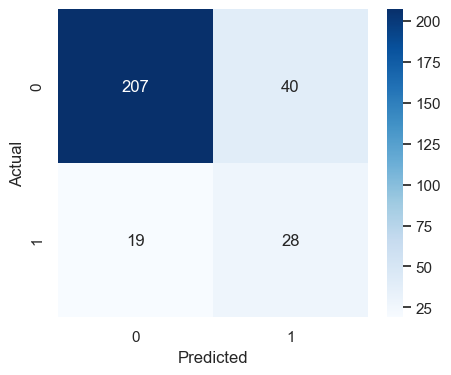

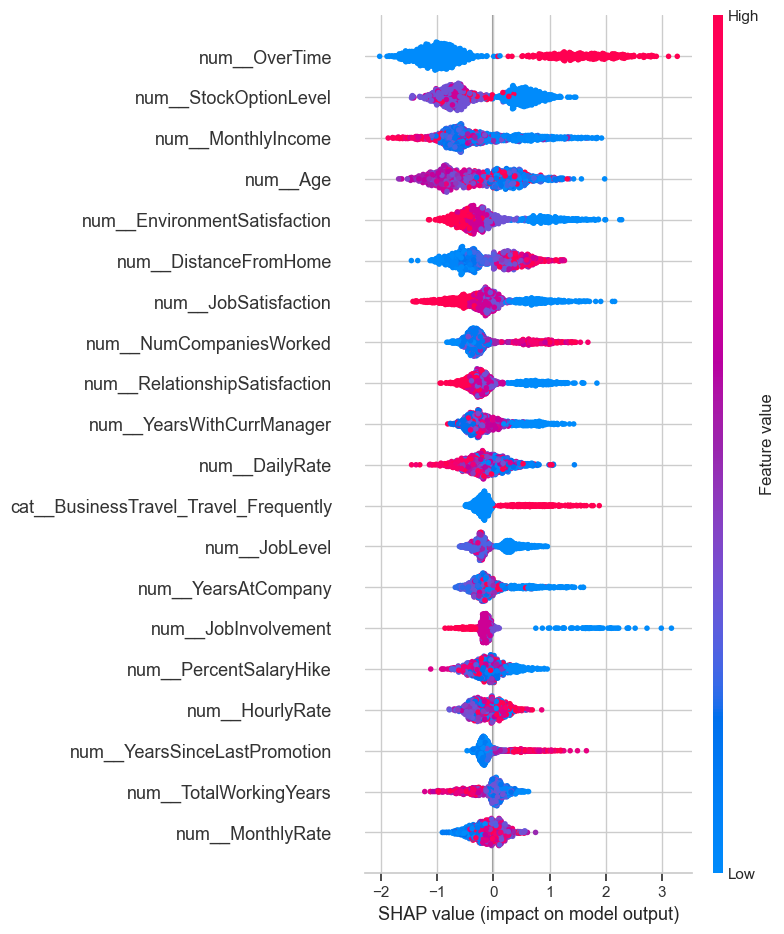

In [18]:
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SHAP Explainer for Interpretability (requires fitting without PCA for better feature names)
# Explaining why the model makes certain decisions
X_processed = preprocessor.fit_transform(X_train)
explainer_model = XGBClassifier().fit(X_processed, y_train)
explainer = shap.TreeExplainer(explainer_model)
shap_values = explainer.shap_values(X_processed)

shap.summary_plot(shap_values, X_processed, feature_names=preprocessor.get_feature_names_out())

#### Export for Streamlit

In [19]:
import joblib
# Save the full pipeline
joblib.dump(best_model, 'attrition_model_pipeline.pkl')
print("Model Exported Successfully!")

Model Exported Successfully!


### 7. Conclusion & Insights

**Financial Stability**: Monthly Income and Stock Options are major predictors of retention.

**Burnout**: Overtime is a critical driver for attrition.

**Tenure**: The first two years are high-risk periods for new hires.

**Model Performance**: The XGBoost pipeline with SMOTE and PCA provides a balanced approach to predicting the minority class (employees leaving).